In [5]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

In [6]:
path = "/home/slow_data/Air_Quality/GIS/2025/09/01/"

data = "3B-HHR-GIS.MS.MRG.3IMERG.20250901-S140000-E142959.0840.V07B"

In [7]:
# geotiff_path = '/home/work1/projects/Air_Quality/GIS data/3B-DAY-L.GIS.IMERG.20250901.V07B.tif'

In [8]:
import zipfile

zip_file_path = path + data+ ".zip"
extract_to_path = path + data + "/"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

print(f"All files extracted from '{zip_file_path}' to '{extract_to_path}'.")

All files extracted from '/home/slow_data/Air_Quality/GIS/2025/09/01/3B-HHR-GIS.MS.MRG.3IMERG.20250901-S140000-E142959.0840.V07B.zip' to '/home/slow_data/Air_Quality/GIS/2025/09/01/3B-HHR-GIS.MS.MRG.3IMERG.20250901-S140000-E142959.0840.V07B/'.


Image dimensions: 3600x1800
Number of bands: 1
Coordinate Reference System (CRS): EPSG:4326
Bounding box: BoundingBox(left=-180.0, bottom=-90.00000268220901, right=180.00000536441803, top=90.0)
Transform (affine transformation): | 0.10, 0.00,-180.00|
| 0.00,-0.10, 90.00|
| 0.00, 0.00, 1.00|


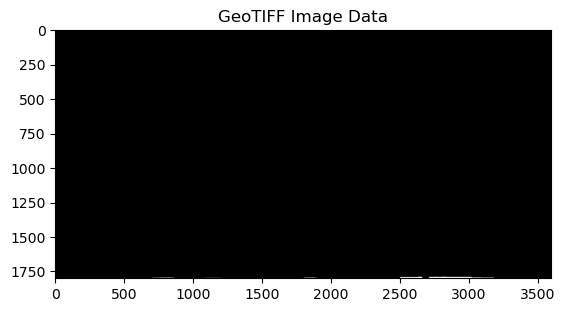

In [9]:
# Define the path to your GeoTIFF file
geotiff_path = path + data + '/' + data + '.total.accum.tif'

# Open the GeoTIFF file
with rasterio.open(geotiff_path) as src:
    # Read the entire image data into a NumPy array (first band by default)
    image_data = src.read(1)  # Read band 1 (indexing starts from 1)

    # You can also read specific bands
    # band_2_data = src.read(2)

    # Access metadata and georeferencing information
    print(f"Image dimensions: {src.width}x{src.height}")
    print(f"Number of bands: {src.count}")
    # print(f"NaN value: {src.nodata}")
    print(f"Coordinate Reference System (CRS): {src.crs}")
    print(f"Bounding box: {src.bounds}")
    print(f"Transform (affine transformation): {src.transform}")

    # You can perform further operations with image_data (e.g., visualization, analysis)
    # For example, to visualize (requires matplotlib):

    plt.imshow(image_data, cmap='gray')
    plt.title("GeoTIFF Image Data")
    plt.show()

In [10]:
print("Min:", image_data.min())
print("Max:", image_data.max())
print("Unique values:", np.unique(image_data))
print("Data type:", image_data.dtype)

Min: 0
Max: 29999
Unique values: [    0     1     2     3     4     5     6     7     8     9    10    11
    12    13    14    15    16    17    18    19    20    21    22    23
    24    25    26    27    28    29    30    31    32    33    34    35
    36    37    38    39    40    41    42    43    44    45    46    47
    48    49    50    51    52    53    54    55    56    57    58    59
    60    61    62    63    64    65    66    67    68    69    70    71
    72    73    74    75    76    77    78    79    80    81    82    83
    84    85    86    87    88    89    90    91    92    93    94    95
    96    97    98    99   100   101   102   103   104   105   106   107
   108   109   110   111   112   113   114   115   116   117   118   119
   120   121   122   123   124   125   126   127   128   129   130   131
   132   133   134   135   136   137   138   139   140   141   142   143
   144   145   146   147   148   149   150   151   152   154   155   156
   157   158   159

In [11]:

# assume image_data is your array
nodata_value = 29999
mask = (image_data == nodata_value)

# convert to float so you can use NaN
rain = image_data.astype(float)
rain[mask] = np.nan

# optionally scale (IMERG Final Run 30 min: scale = 0.1 mm)  
rain_mm = rain * 0.1


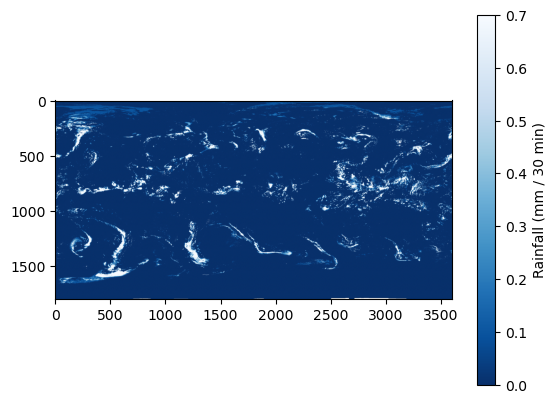

In [12]:
plt.imshow(rain_mm, cmap='Blues_r', vmin=0, vmax=np.nanpercentile(rain_mm, 98))
plt.colorbar(label='Rainfall (mm / 30 min)')
plt.show()